In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df_country = pd.read_csv('Country-data.csv')

In [3]:
df_country

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


### Imputando valores nulos

In [4]:
df_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


No hay existencia de valores nulos

### Validando duplicados 

In [5]:
df_country[df_country.duplicated()]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp


### Análisis de distribución

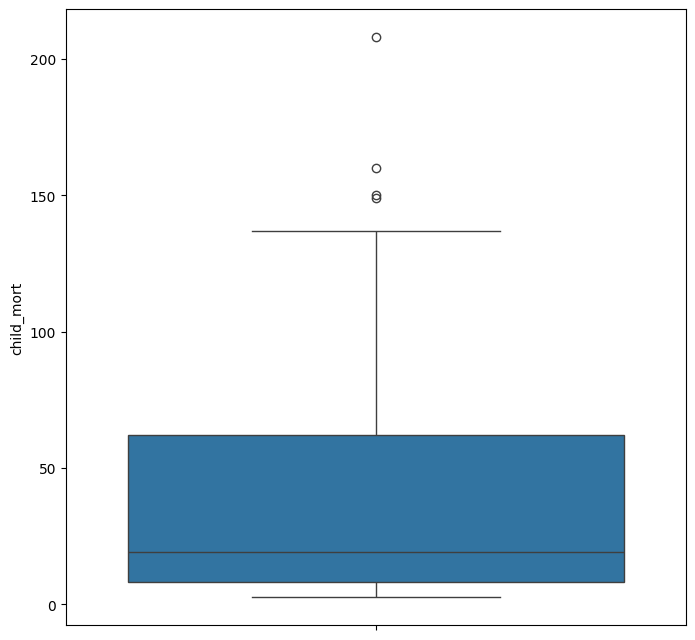

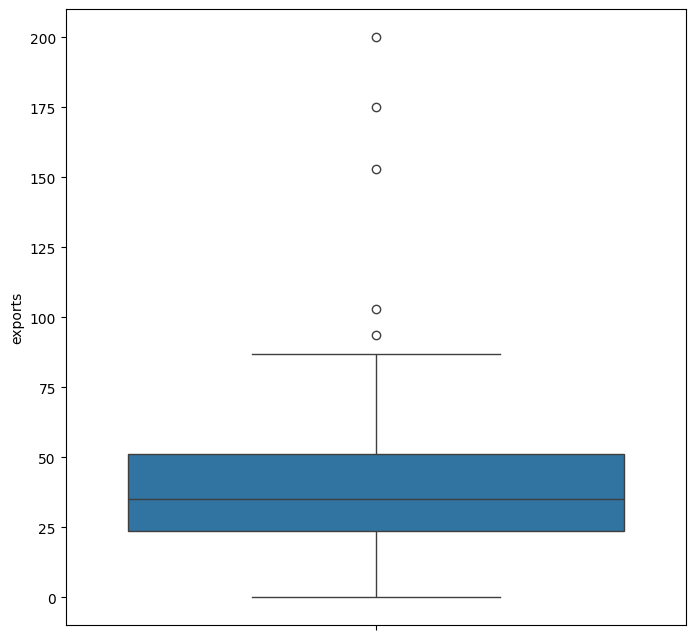

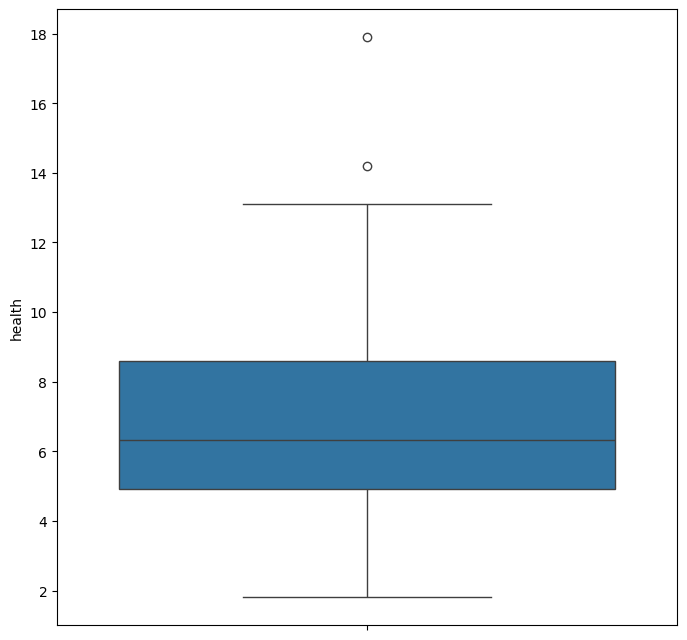

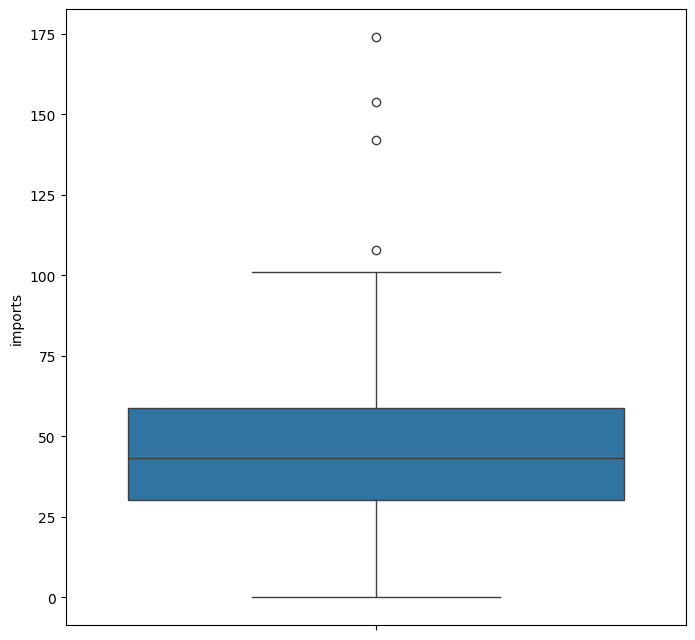

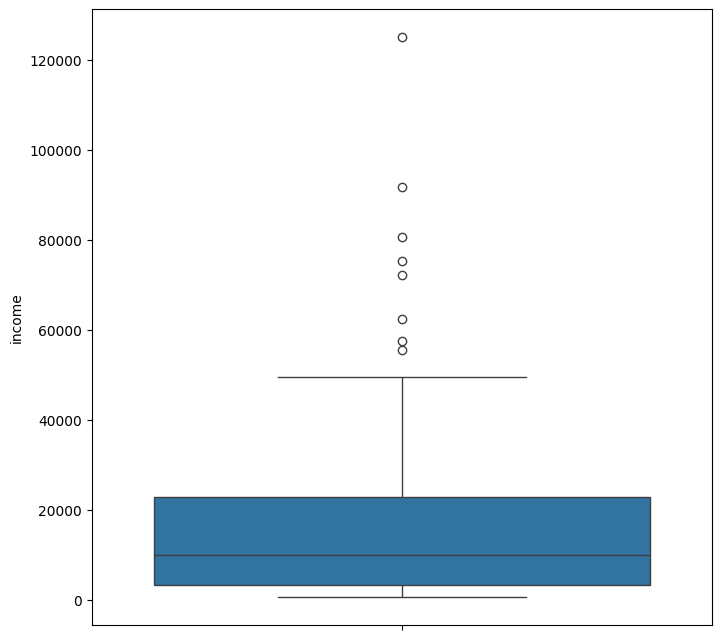

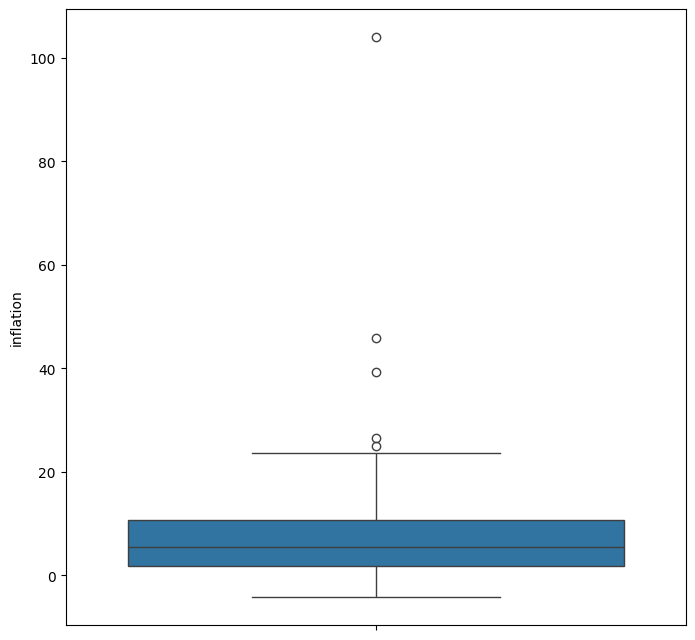

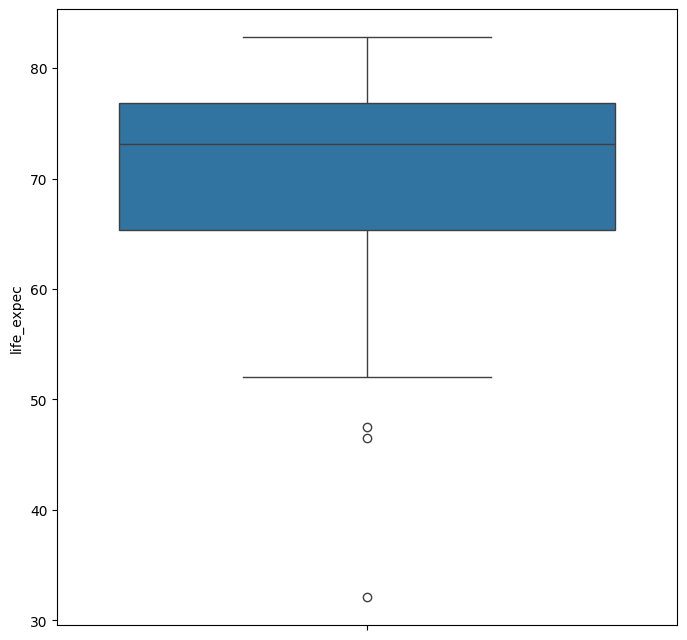

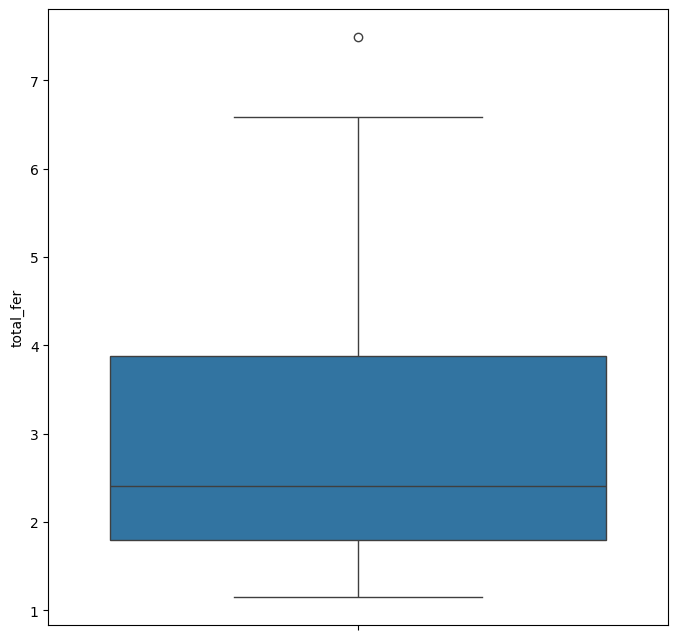

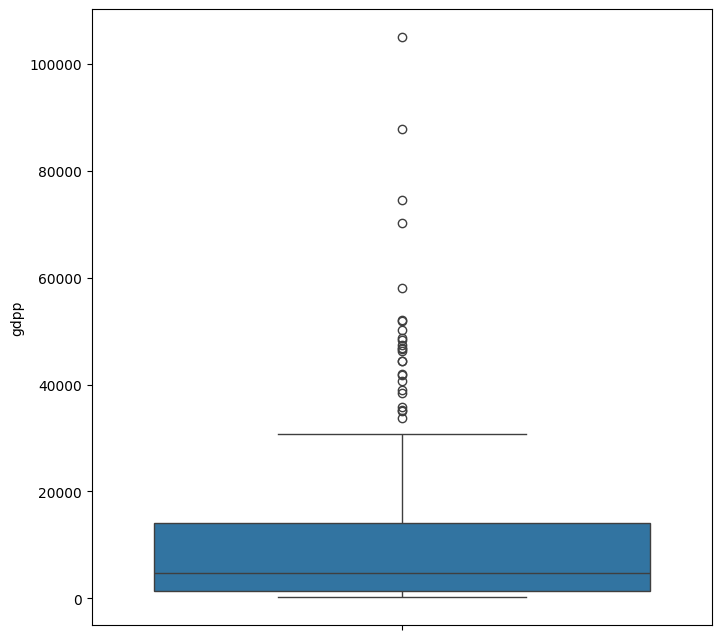

In [6]:
# seleccionaremos todas las columnas de tipo object para buscar outliers estadísticos

int_cols = df_country.select_dtypes(exclude='object').columns
for _ in int_cols:
    plt.figure(figsize=(8,8))
    sns.boxplot(data=df_country, y= _)
    plt.show()

In [7]:
# observamos valores atípicos en la columna 'inflation', pero luego de revisar la métrica se confirmo
# que el valor es real 

df_inflation_sorted = df_country[['country', 'inflation']].sort_values(by='inflation', ascending=False)
df_inflation_sorted

,country,inflation
113,Nigeria,104.000
163,Venezuela,45.900
103,Mongolia,39.200
149,Timor-Leste,26.500
49,Equatorial Guinea,24.900
...,...,...
135,Slovenia,-0.987
43,Czech Republic,-1.430
77,Japan,-1.900
73,Ireland,-3.220


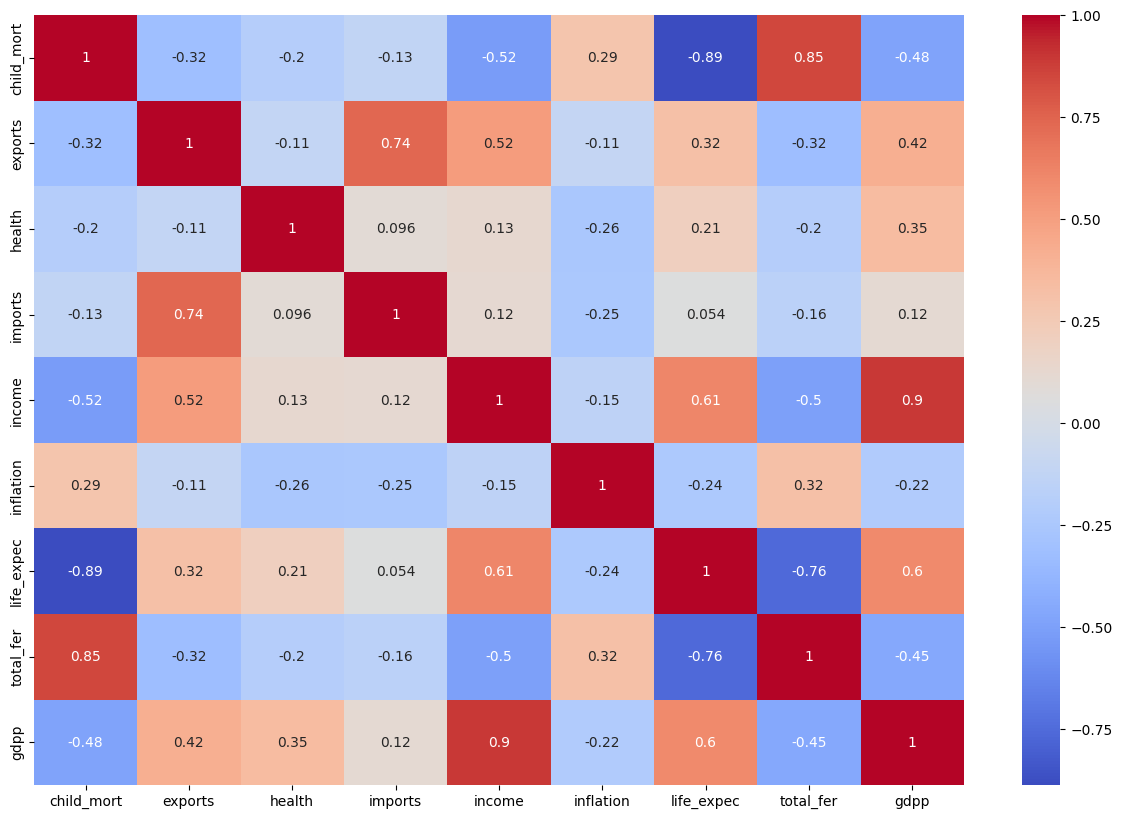

In [8]:
# procederemos a crear una matriz de correlacion de variables

df_numeric = df_country.select_dtypes(include=['float64', 'int64'])

fig = plt.figure(figsize=(15,10))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

Análisis de correlaciones
Relación entre child_mort y otras variables:

Alta correlación negativa con life_expec (-0.89): Esto indica que los países con una mayor esperanza de vida suelen tener menores tasas de mortalidad infantil, lo cual es coherente con el acceso a mejores sistemas de salud y condiciones de vida.
Alta correlación positiva con total_fer (0.85): Los países con mayor tasa de mortalidad infantil tienden a tener tasas de fertilidad más altas, lo que puede ser indicativo de economías en desarrollo o sistemas de salud menos avanzados.
Relación entre income y gdpp:

Alta correlación positiva (0.9): Este comportamiento sugiere que un mayor ingreso promedio por persona está estrechamente relacionado con un mayor producto interno bruto per cápita, lo que es un reflejo de economías más desarrolladas.
Relación entre exports e imports:

Alta correlación positiva (0.74): Esto indica que los países que tienen una economía abierta al comercio internacional tienden a tener tanto altas exportaciones como importaciones.
Relación entre inflation y otras variables:

Correlación moderada positiva con exports (0.32): Esto puede ser indicativo de ciertos países donde un crecimiento en las exportaciones está relacionado con un aumento en los niveles de inflación, tal vez debido a un incremento en la demanda interna o a políticas económicas expansivas.
Correlación negativa con income (-0.15): Aunque es débil, muestra que países con altos ingresos tienden a tener inflaciones más controladas.
Relación entre life_expec y gdpp:

Correlación positiva moderada (0.6): Los países con una mayor esperanza de vida tienden a tener un PIB per cápita más alto, lo que puede ser indicativo de mejores sistemas de salud y mayores niveles de desarrollo.
Relación entre total_fer y otras variables:

Alta correlación negativa con life_expec (-0.76): Esto refuerza la idea de que los países con altas tasas de fertilidad suelen tener una esperanza de vida más baja, probablemente debido a limitaciones en recursos y desarrollo.


Conclusiones principales
Las variables income y gdpp son indicadores clave de desarrollo económico y están altamente relacionadas.
La mortalidad infantil (child_mort) es un reflejo del desarrollo socioeconómico, con conexiones profundas con variables como la esperanza de vida (life_expec) y la fertilidad (total_fer).
Las economías abiertas al comercio internacional muestran una estrecha relación entre exportaciones e importaciones.
La inflación no parece tener un impacto muy fuerte en otras variables, aunque tiene conexiones débiles con exports e income.

### Escalar los datos

In [9]:
from sklearn.preprocessing  import StandardScaler

scaaler = StandardScaler()
df_country_scaled = scaaler.fit_transform(df_numeric)



In [10]:
df_country_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

In [11]:
# lo convertimos en un dataframe

df_country_scaled = pd.DataFrame(df_country_scaled, columns=df_country.drop('country', axis=1).columns)

In [12]:
df_country_scaled

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
...,...,...,...,...,...,...,...,...,...
162,-0.225578,0.200917,-0.571711,0.240700,-0.738527,-0.489784,-0.852161,0.365754,-0.546913
163,-0.526514,-0.461363,-0.695862,-1.213499,-0.033542,3.616865,0.546361,-0.316678,0.029323
164,-0.372315,1.130305,0.008877,1.380030,-0.658404,0.409732,0.286958,-0.661206,-0.637754
165,0.448417,-0.406478,-0.597272,-0.517472,-0.658924,1.500916,-0.344633,1.140944,-0.637754


### PCA

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_country_scaled)
pca_data_scaled = pca.transform(df_country_scaled)
pca_data_scaled




array([[-2.91302459,  0.09562058, -0.7181185 , ..., -0.38300026,
        -0.41507602,  0.01414844],
       [ 0.42991133, -0.58815567, -0.3334855 , ..., -0.24891887,
         0.22104247, -0.17331578],
       [-0.28522508, -0.45517441,  1.22150481, ...,  0.08721359,
         0.18416209, -0.08403718],
       ...,
       [ 0.49852439,  1.39074432, -0.23852611, ...,  0.14362677,
         0.21759009,  0.03652231],
       [-1.88745106, -0.10945301,  1.10975159, ..., -0.06025631,
        -0.08949452,  0.09604924],
       [-2.86406392,  0.48599799,  0.22316658, ...,  0.44218462,
        -0.66433809,  0.44148176]])

In [14]:
var = pca.explained_variance_ratio_
print(var)




[0.4595174  0.17181626 0.13004259 0.11053162 0.07340211 0.02484235
 0.0126043  0.00981282 0.00743056]


In [15]:
pca_df = pd.DataFrame(pca_data_scaled, 
                      columns=[f'PC{i+1}' for i in range(len(var))])

pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-2.913025,0.095621,-0.718118,1.005255,-0.158310,0.254597,-0.383000,-0.415076,0.014148
1,0.429911,-0.588156,-0.333486,-1.161059,0.174677,-0.084579,-0.248919,0.221042,-0.173316
2,-0.285225,-0.455174,1.221505,-0.868115,0.156475,0.401696,0.087214,0.184162,-0.084037
3,-2.932423,1.695555,1.525044,0.839625,-0.273209,0.547996,0.440835,0.355998,0.091339
4,1.033576,0.136659,-0.225721,-0.847063,-0.193007,0.206919,-0.241978,0.023681,-0.094270
...,...,...,...,...,...,...,...,...,...
162,-0.820631,0.639570,-0.389923,-0.706595,-0.395748,-0.009059,0.098738,-0.521886,0.497803
163,-0.551036,-1.233886,3.101350,-0.115311,2.082581,-0.097274,-0.206735,0.078805,0.275735
164,0.498524,1.390744,-0.238526,-1.074098,1.176081,-0.051607,0.143627,0.217590,0.036522
165,-1.887451,-0.109453,1.109752,0.056257,0.618365,0.540917,-0.060256,-0.089495,0.096049


### Varianza explicada

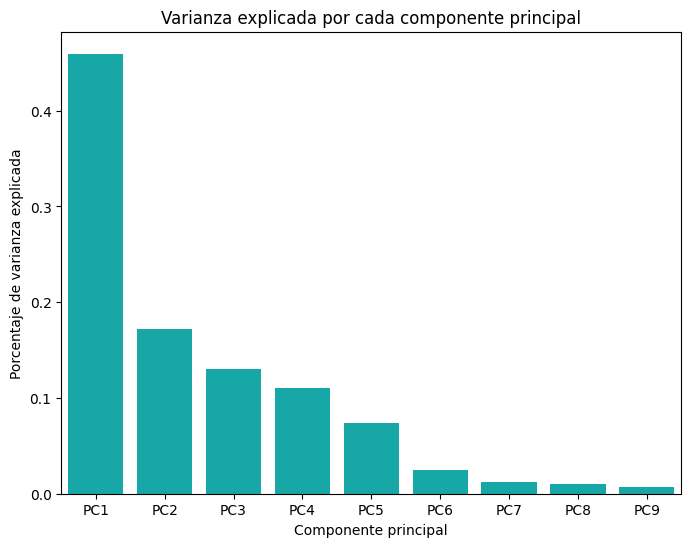

In [16]:
plt.figure(figsize=(8,6))
sns.barplot(x=[f'PC{i+1}' for i in range(len(var))], y=var, color='c')
plt.title('Varianza explicada por cada componente principal')
plt.xlabel('Componente principal')
plt.ylabel('Porcentaje de varianza explicada')
plt.show()

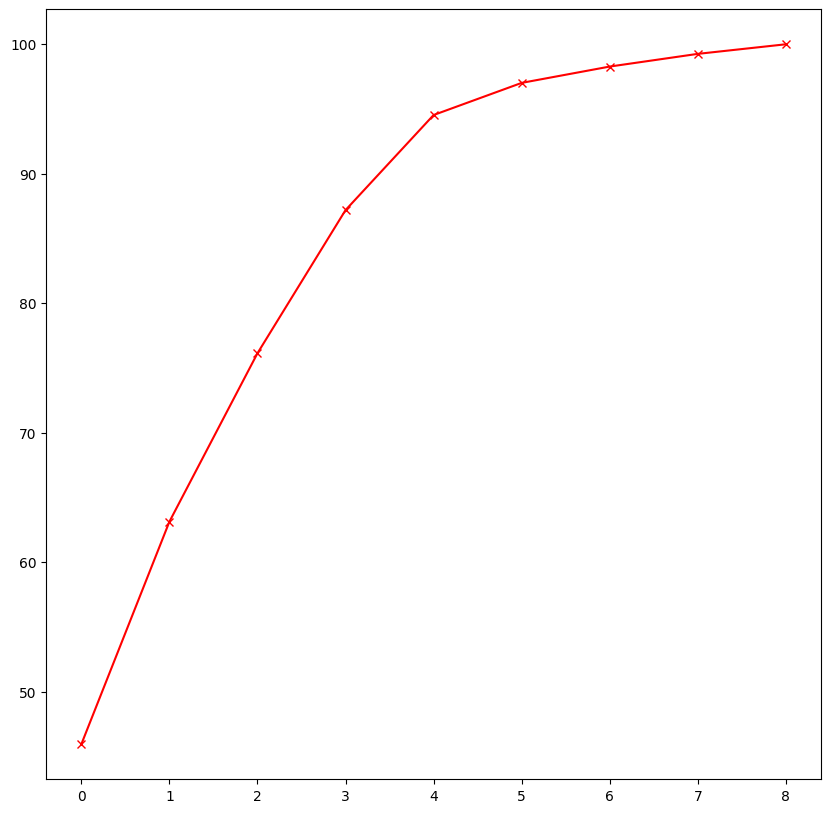

In [17]:
cum_var = np.cumsum(np.round(var, decimals=4)*100)
plt.figure(figsize=(10,10))
plt.plot(cum_var, 'r-x')

In [18]:
pca_data_standar = pd.DataFrame(pca_data_scaled)
pca_data_standar.drop([4,5,6,7,8], axis=1, inplace=True)
pca_data_standar

,0,1,2,3
0,-2.913025,0.095621,-0.718118,1.005255
1,0.429911,-0.588156,-0.333486,-1.161059
2,-0.285225,-0.455174,1.221505,-0.868115
3,-2.932423,1.695555,1.525044,0.839625
4,1.033576,0.136659,-0.225721,-0.847063
...,...,...,...,...
162,-0.820631,0.639570,-0.389923,-0.706595
163,-0.551036,-1.233886,3.101350,-0.115311
164,0.498524,1.390744,-0.238526,-1.074098
165,-1.887451,-0.109453,1.109752,0.056257


## Clustering

### Importamos librerías para clustering

In [19]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

### K-means

#### PCA

In [20]:
sum_of_squared_distance = []
silhouette_scores = []
k = range(2,15)
for _ in k:
    km = KMeans(n_clusters=_)
    y = km.fit_predict(pca_data_standar)
    sum_of_squared_distance.append(km.inertia_)
    silhouette_scores.append(silhouette_score(pca_data_standar, y))

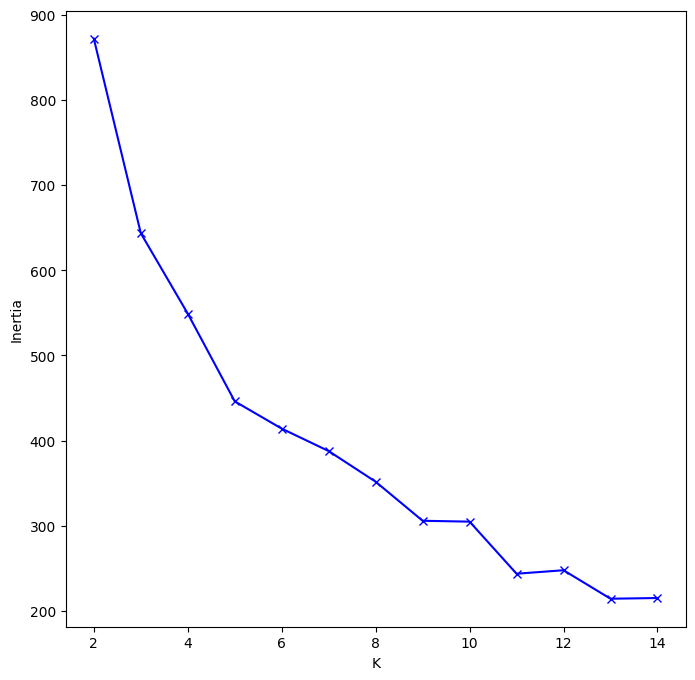

In [22]:
fig = plt.figure(figsize=(8,8))
plt.plot(k, sum_of_squared_distance, 'bx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

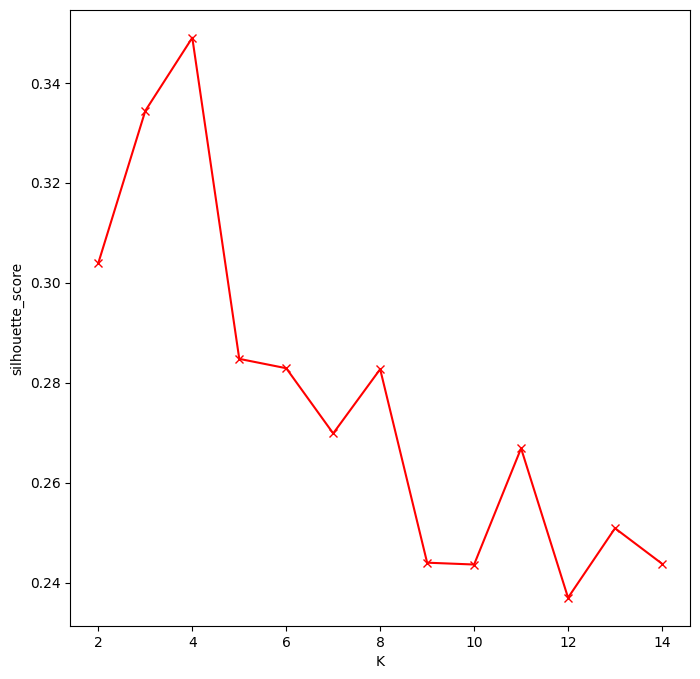

In [21]:
fig = plt.figure(figsize=(8,8))
plt.plot(k, silhouette_scores, 'rx-')
plt.xlabel('K')
plt.ylabel('silhouette_score')
plt.show()

In [22]:
# procederemos a entrenar K-means con 4 clusters 
km = KMeans(n_clusters=4)
y = km.fit_predict(pca_data_standar)
print(silhouette_score(pca_data_standar, y))
df_country['K_means_PCA'] = y

0.35491314499063326


##### Sin PCA

In [23]:
sum_of_squared_distance = []
silhouette_scores = []
k = range(2,15)
for _ in k:
    km = KMeans(n_clusters=_)
    y = km.fit_predict(df_country_scaled)
    sum_of_squared_distance.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df_country_scaled, y))


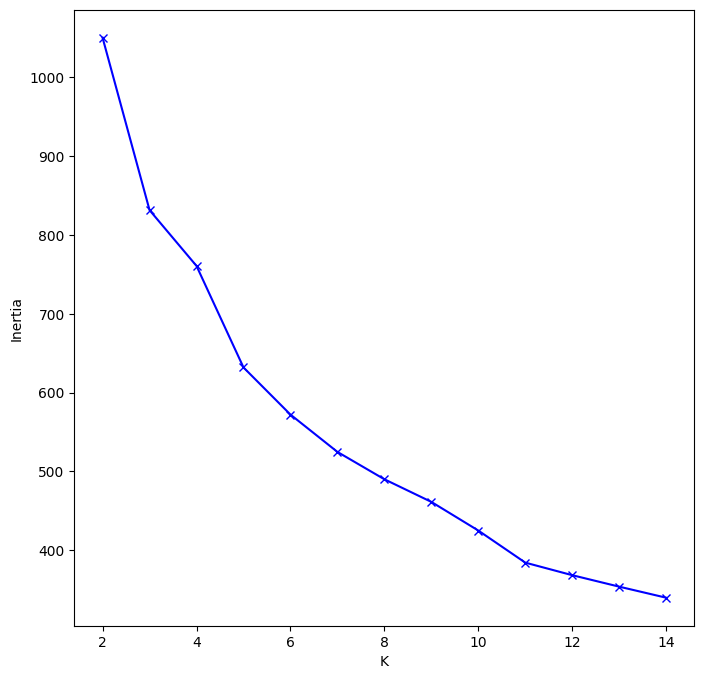

In [24]:
fig = plt.figure(figsize=(8,8))
plt.plot(k, sum_of_squared_distance, 'bx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

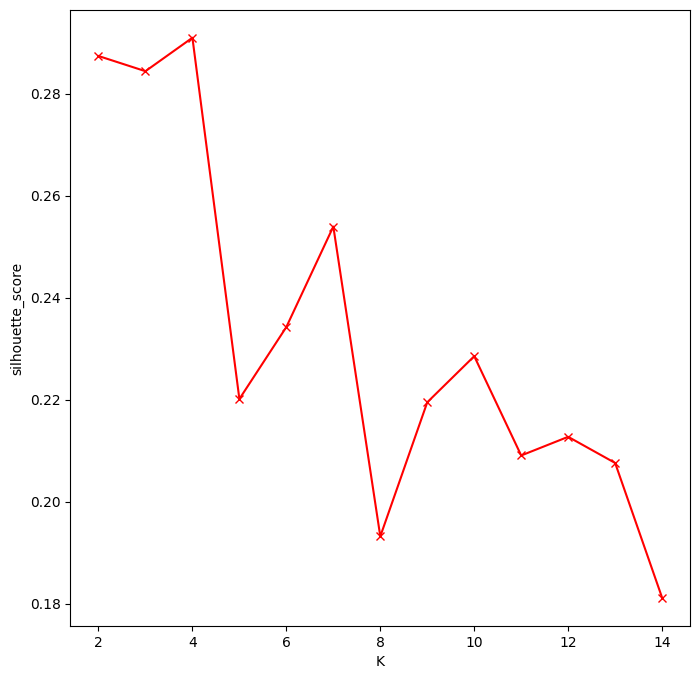

In [25]:
fig = plt.figure(figsize=(8,8))
plt.plot(k, silhouette_scores, 'rx-')
plt.xlabel('K')
plt.ylabel('silhouette_score')
plt.show()

In [26]:
# evaluamos el silhouette score

km = KMeans(n_clusters=5)
y = km.fit_predict(df_country_scaled)
print(silhouette_score(df_country_scaled, y))
df_country['k_means'] = y

0.2041870615859436


## Agglomerativen Hierarchical Clustering

####  PCA

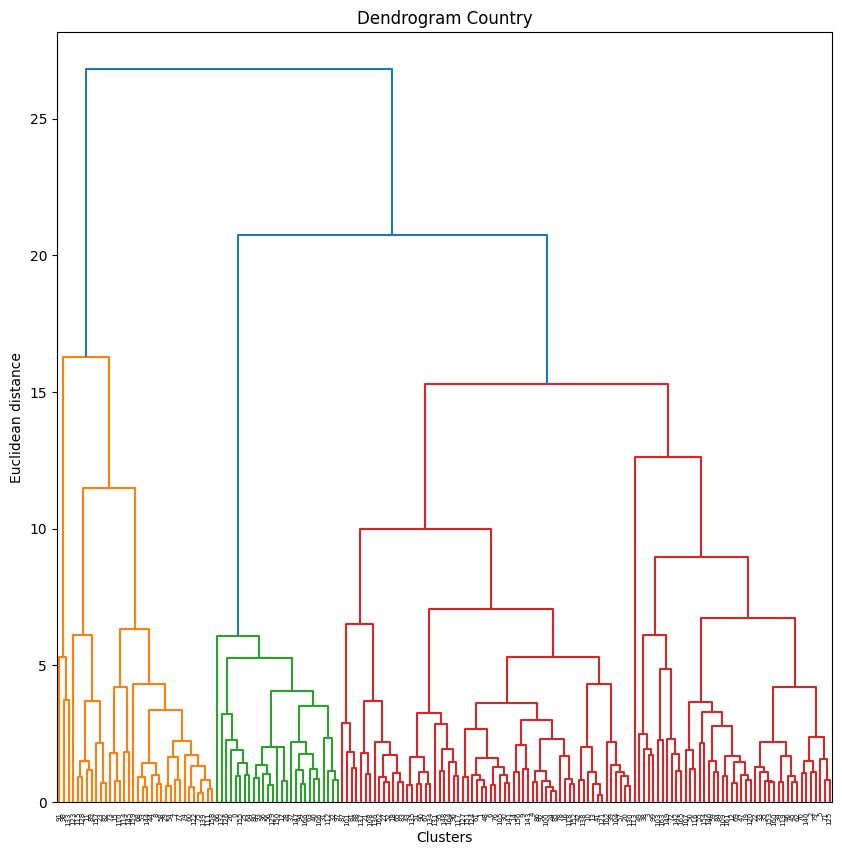

In [27]:
fig = plt.figure(figsize=(10,10))
dendrogram_plot = dendrogram(linkage(pca_data_scaled, method='ward'))
plt.title('Dendrogram Country')
plt.xlabel('Clusters')
plt.ylabel('Euclidean distance')
plt.show()

In [28]:
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(pca_data_standar)
print(silhouette_score(pca_data_standar, y_hc))
df_country['hc_pca'] = y_hc

0.3070110704080525


#### Sin PCA

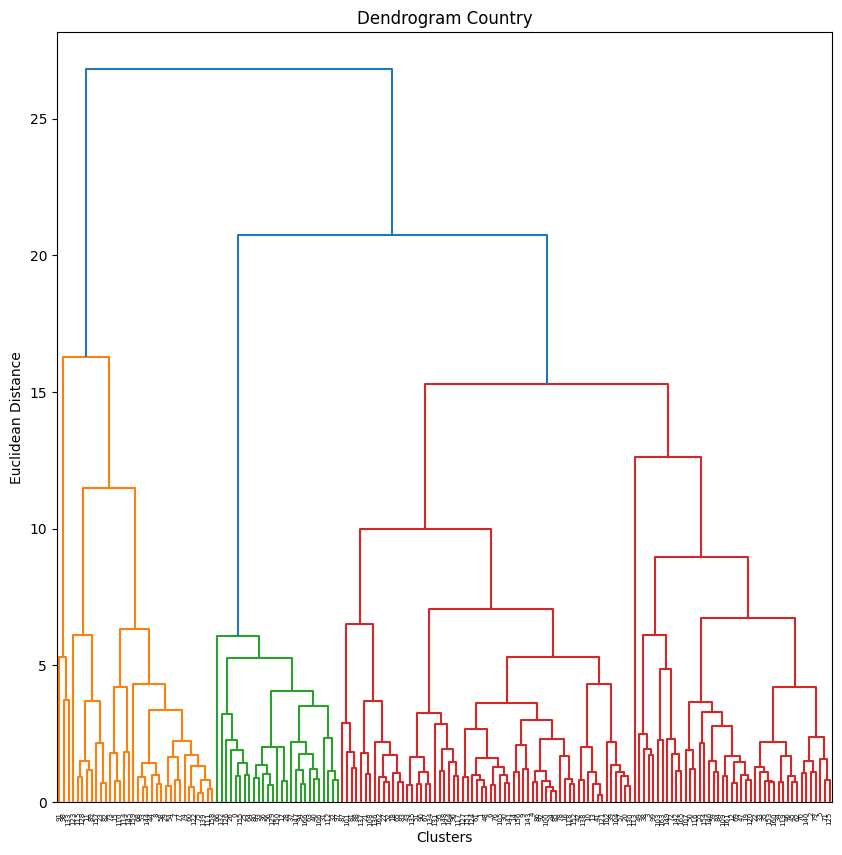

In [29]:
fig = plt.figure(figsize=(10,10))
dendrogram_plot = dendrogram(linkage(df_country_scaled, method='ward'))
plt.title('Dendrogram Country')
plt.xlabel('Clusters')
plt.ylabel('Euclidean Distance')
plt.show()

In [30]:
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(df_country_scaled)
print(silhouette_score(df_country_scaled, y_hc))
df_country['hc'] = y_hc

0.3153134331018189


## DBSCAN

#### PCA

In [31]:
# primero debemos calcular epsilon

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(pca_data_standar)
distances, indices = neighbors_fit.kneighbors(pca_data_standar)

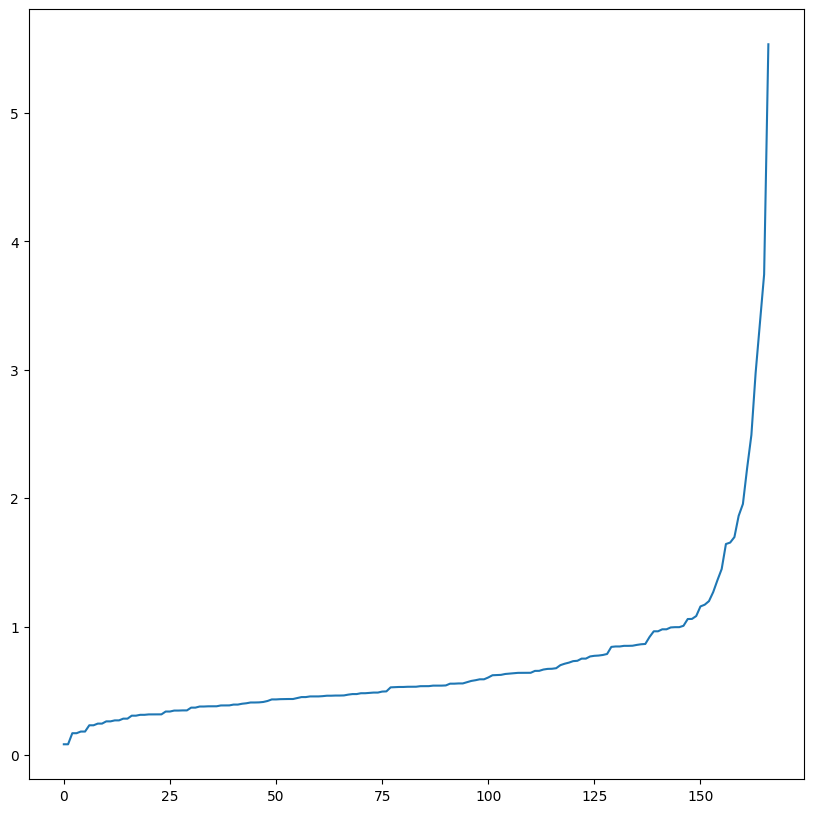

In [32]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
fig = plt.figure(figsize=(10,10))
plt.plot(distances)

In [33]:
eps_values = np.arange(0.5, 2.0, 0.10)
min_samples = np.arange(3,12)

In [34]:
from itertools import product
dbscan_paramns = list(product(eps_values, min_samples))
no_of_clusters = []
sil_score = []
for p in dbscan_paramns:
    y_dbscan = DBSCAN(eps=p[0], min_samples=p[1]).fit_predict(pca_data_standar)
    try:
        sil_score.append(silhouette_score(pca_data_standar, y_dbscan))
    except:
        sil_score.append(0)
    no_of_clusters.append(len(np.unique(y_dbscan)))

In [35]:
df_paramn_tunning = pd.DataFrame.from_records(dbscan_paramns, columns=['Eps', 'Min_samples'])
df_paramn_tunning['sil_score'] = sil_score
df_paramn_tunning['n_clusters'] = no_of_clusters

In [36]:
pivot_1 = pd.pivot_table(df_paramn_tunning, values='sil_score', columns='Eps', index='Min_samples')
pivot_2 = pd.pivot_table(df_paramn_tunning, values='n_clusters', columns='Eps', index='Min_samples')

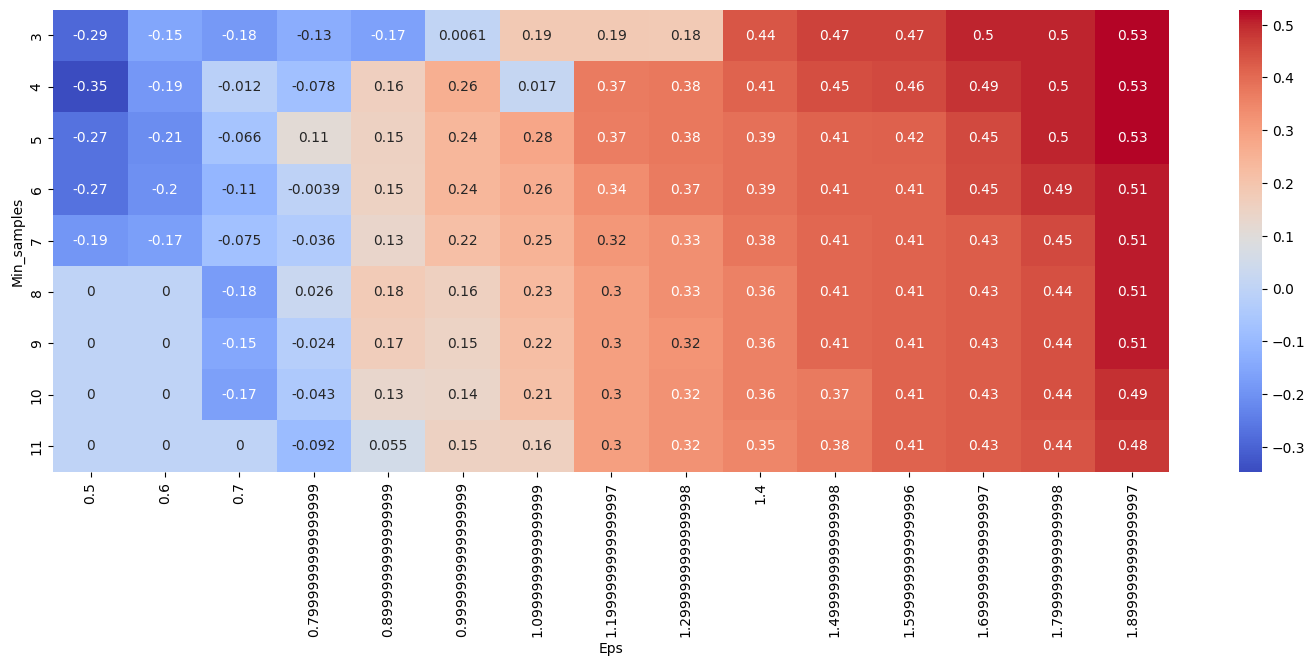

In [37]:
fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_1, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
plt.show()

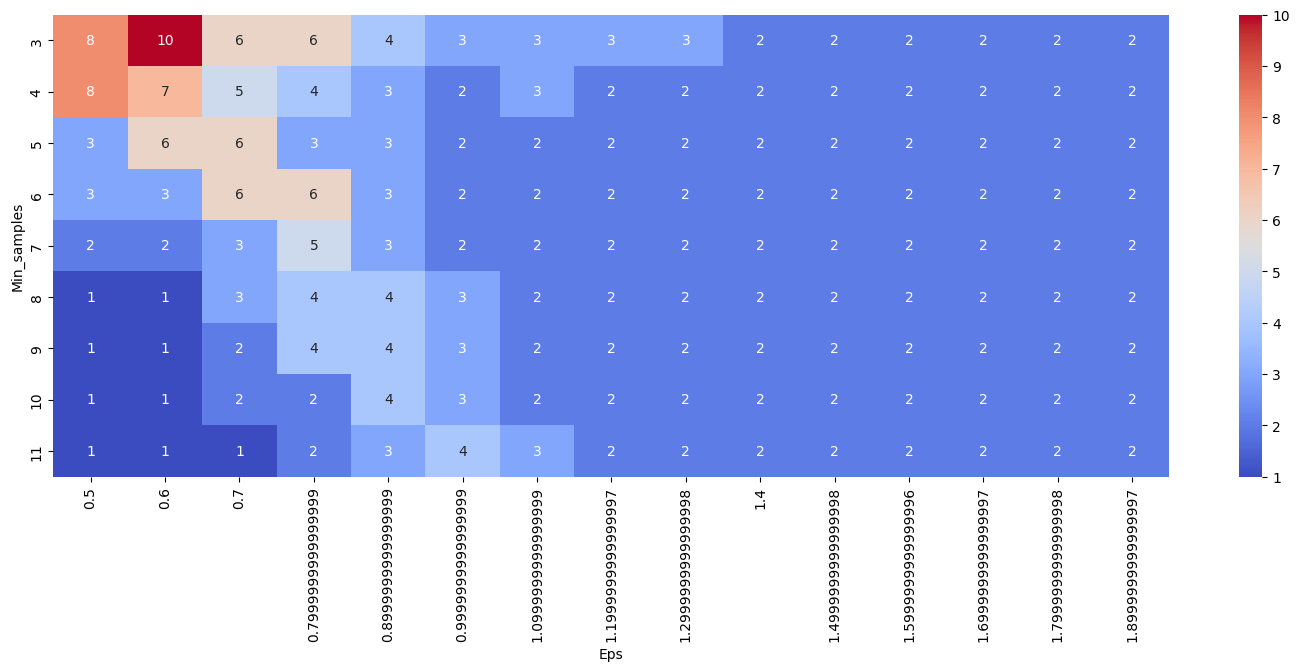

In [38]:
fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_2, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
plt.show()

In [39]:
dbscan_train = DBSCAN(eps=1.2, min_samples=3)
y_dbscan = dbscan_train.fit_predict(pca_data_standar)
print(silhouette_score(pca_data_standar, y_dbscan))
df_country['dbscan_pca'] = y_dbscan

0.1859117573078437


#### Sin PCA

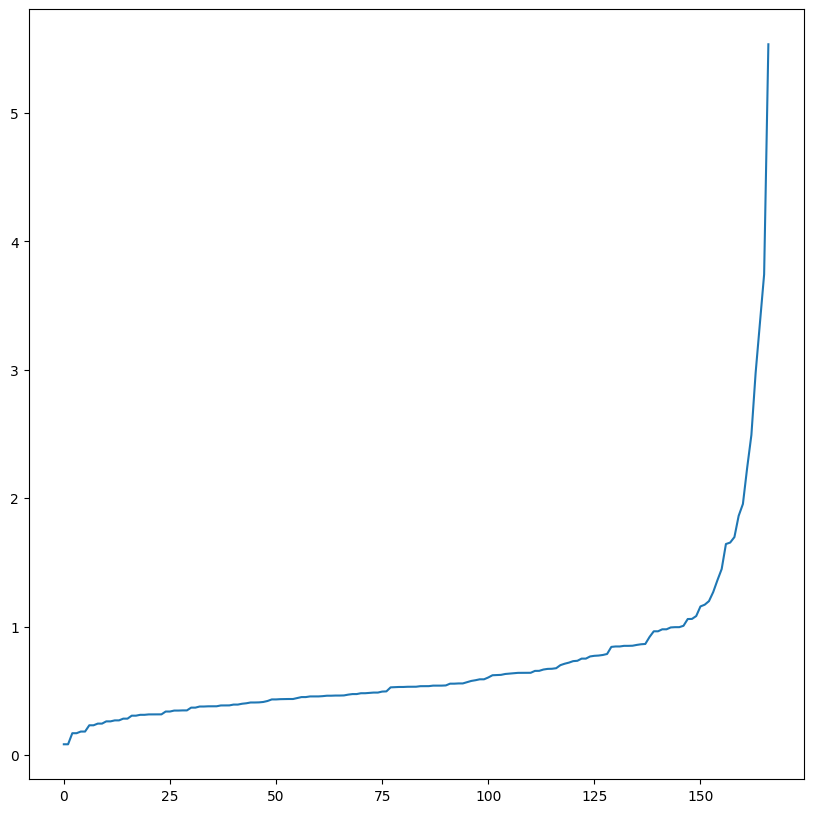

In [40]:
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(pca_data_standar)
distances, indices = neighbors_fit.kneighbors(pca_data_standar)

distances = np.sort(distances,axis=0)
distances = distances[:,1]
fig = plt.figure(figsize=(10,10))
plt.plot(distances)

In [41]:
eps_values = np.arange(1, 3, 0.10)
min_samples = np.arange(3,12)

In [42]:
dbscan_paramns = list(product(eps_values, min_samples))
no_of_clusters = []
sil_score = []
for p in dbscan_paramns:
    y_dbscan = DBSCAN(eps=p[0], min_samples=p[1]).fit_predict(df_country_scaled)
    try:
        sil_score.append(silhouette_score(df_country_scaled, y_dbscan))
    except:
        sil_score.append(0)
    no_of_clusters.append(len(np.unique(y_dbscan)))

In [43]:
df_paramn_tunning = pd.DataFrame.from_records(dbscan_paramns, columns=['Eps', 'Min_samples'])
df_paramn_tunning['sil_score'] = sil_score
df_paramn_tunning['n_clusters'] = no_of_clusters

In [44]:
pivot_1 = pd.pivot_table(df_paramn_tunning, values='sil_score', columns='Eps', index='Min_samples')
pivot_2 = pd.pivot_table(df_paramn_tunning, values='n_clusters', columns='Eps', index='Min_samples')


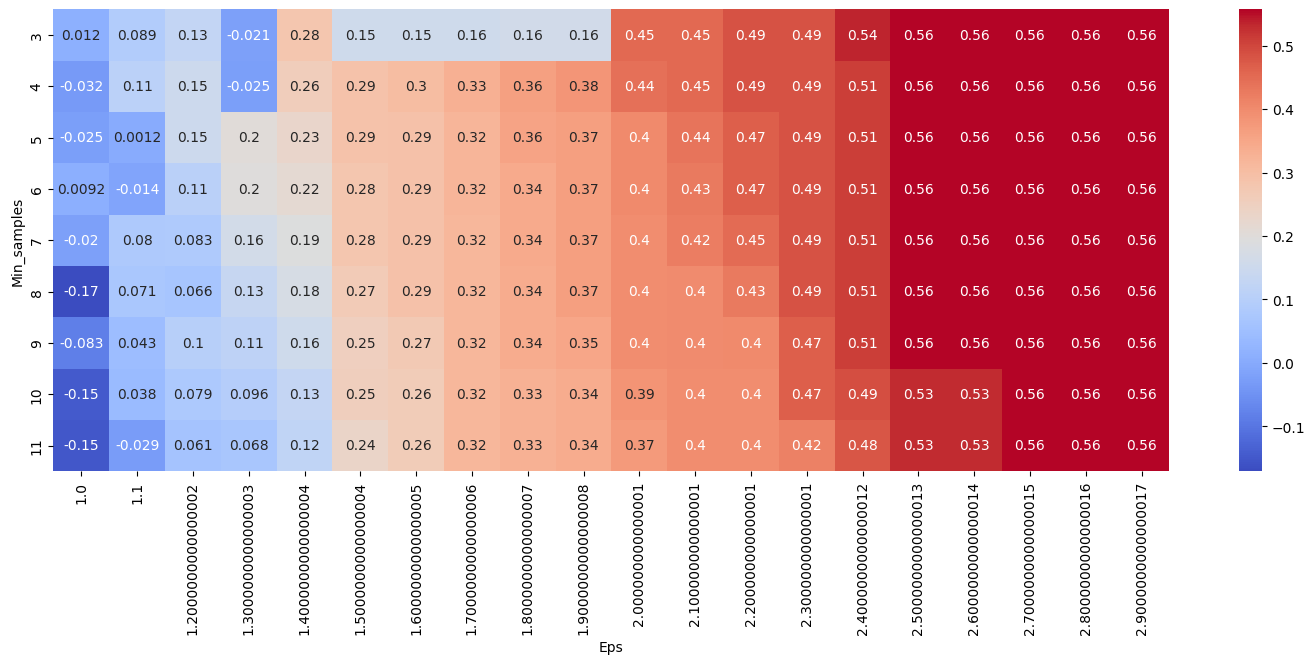

In [45]:
fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_1, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
plt.show()

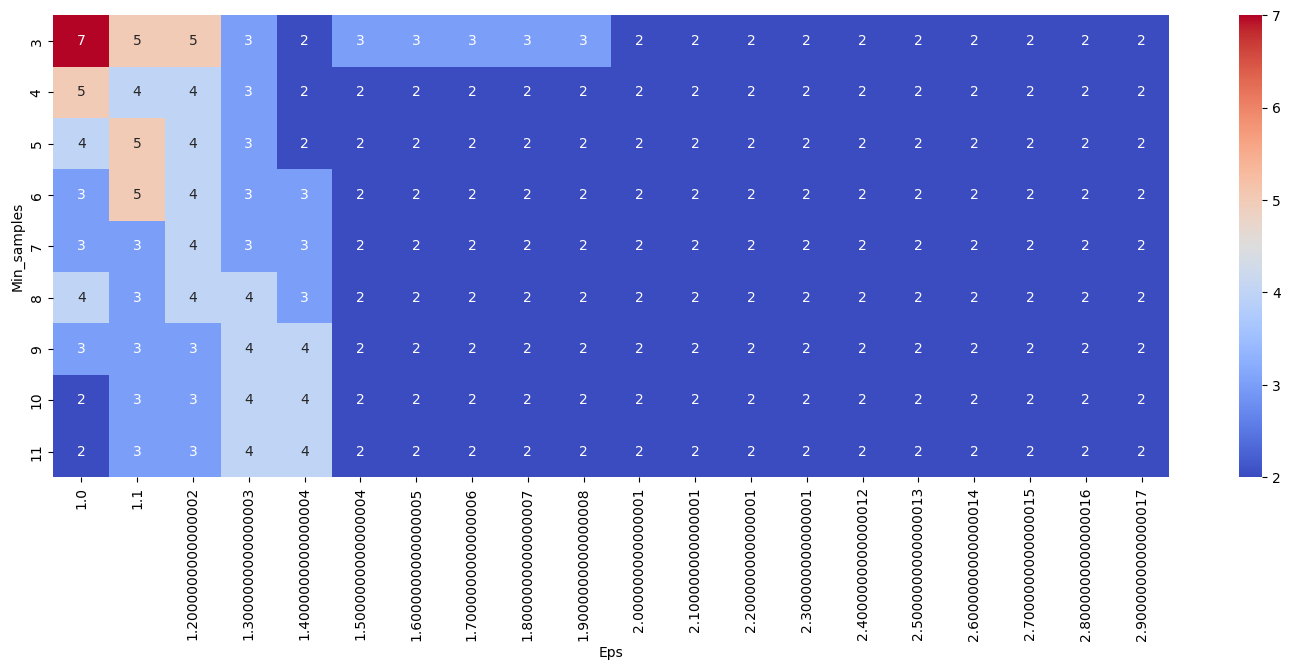

In [46]:
fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_2, annot=True, annot_kws={'size':10}, cmap='coolwarm', ax=ax)
plt.show()

In [47]:
dbscan_train = DBSCAN(eps=1.7, min_samples=3)
y_dbscan = dbscan_train.fit_predict(df_country_scaled)
print(silhouette_score(df_country_scaled, y_dbscan))
df_country['dbscan_cluster'] = y_dbscan

0.1563549566374231


### Evaluación de resultados

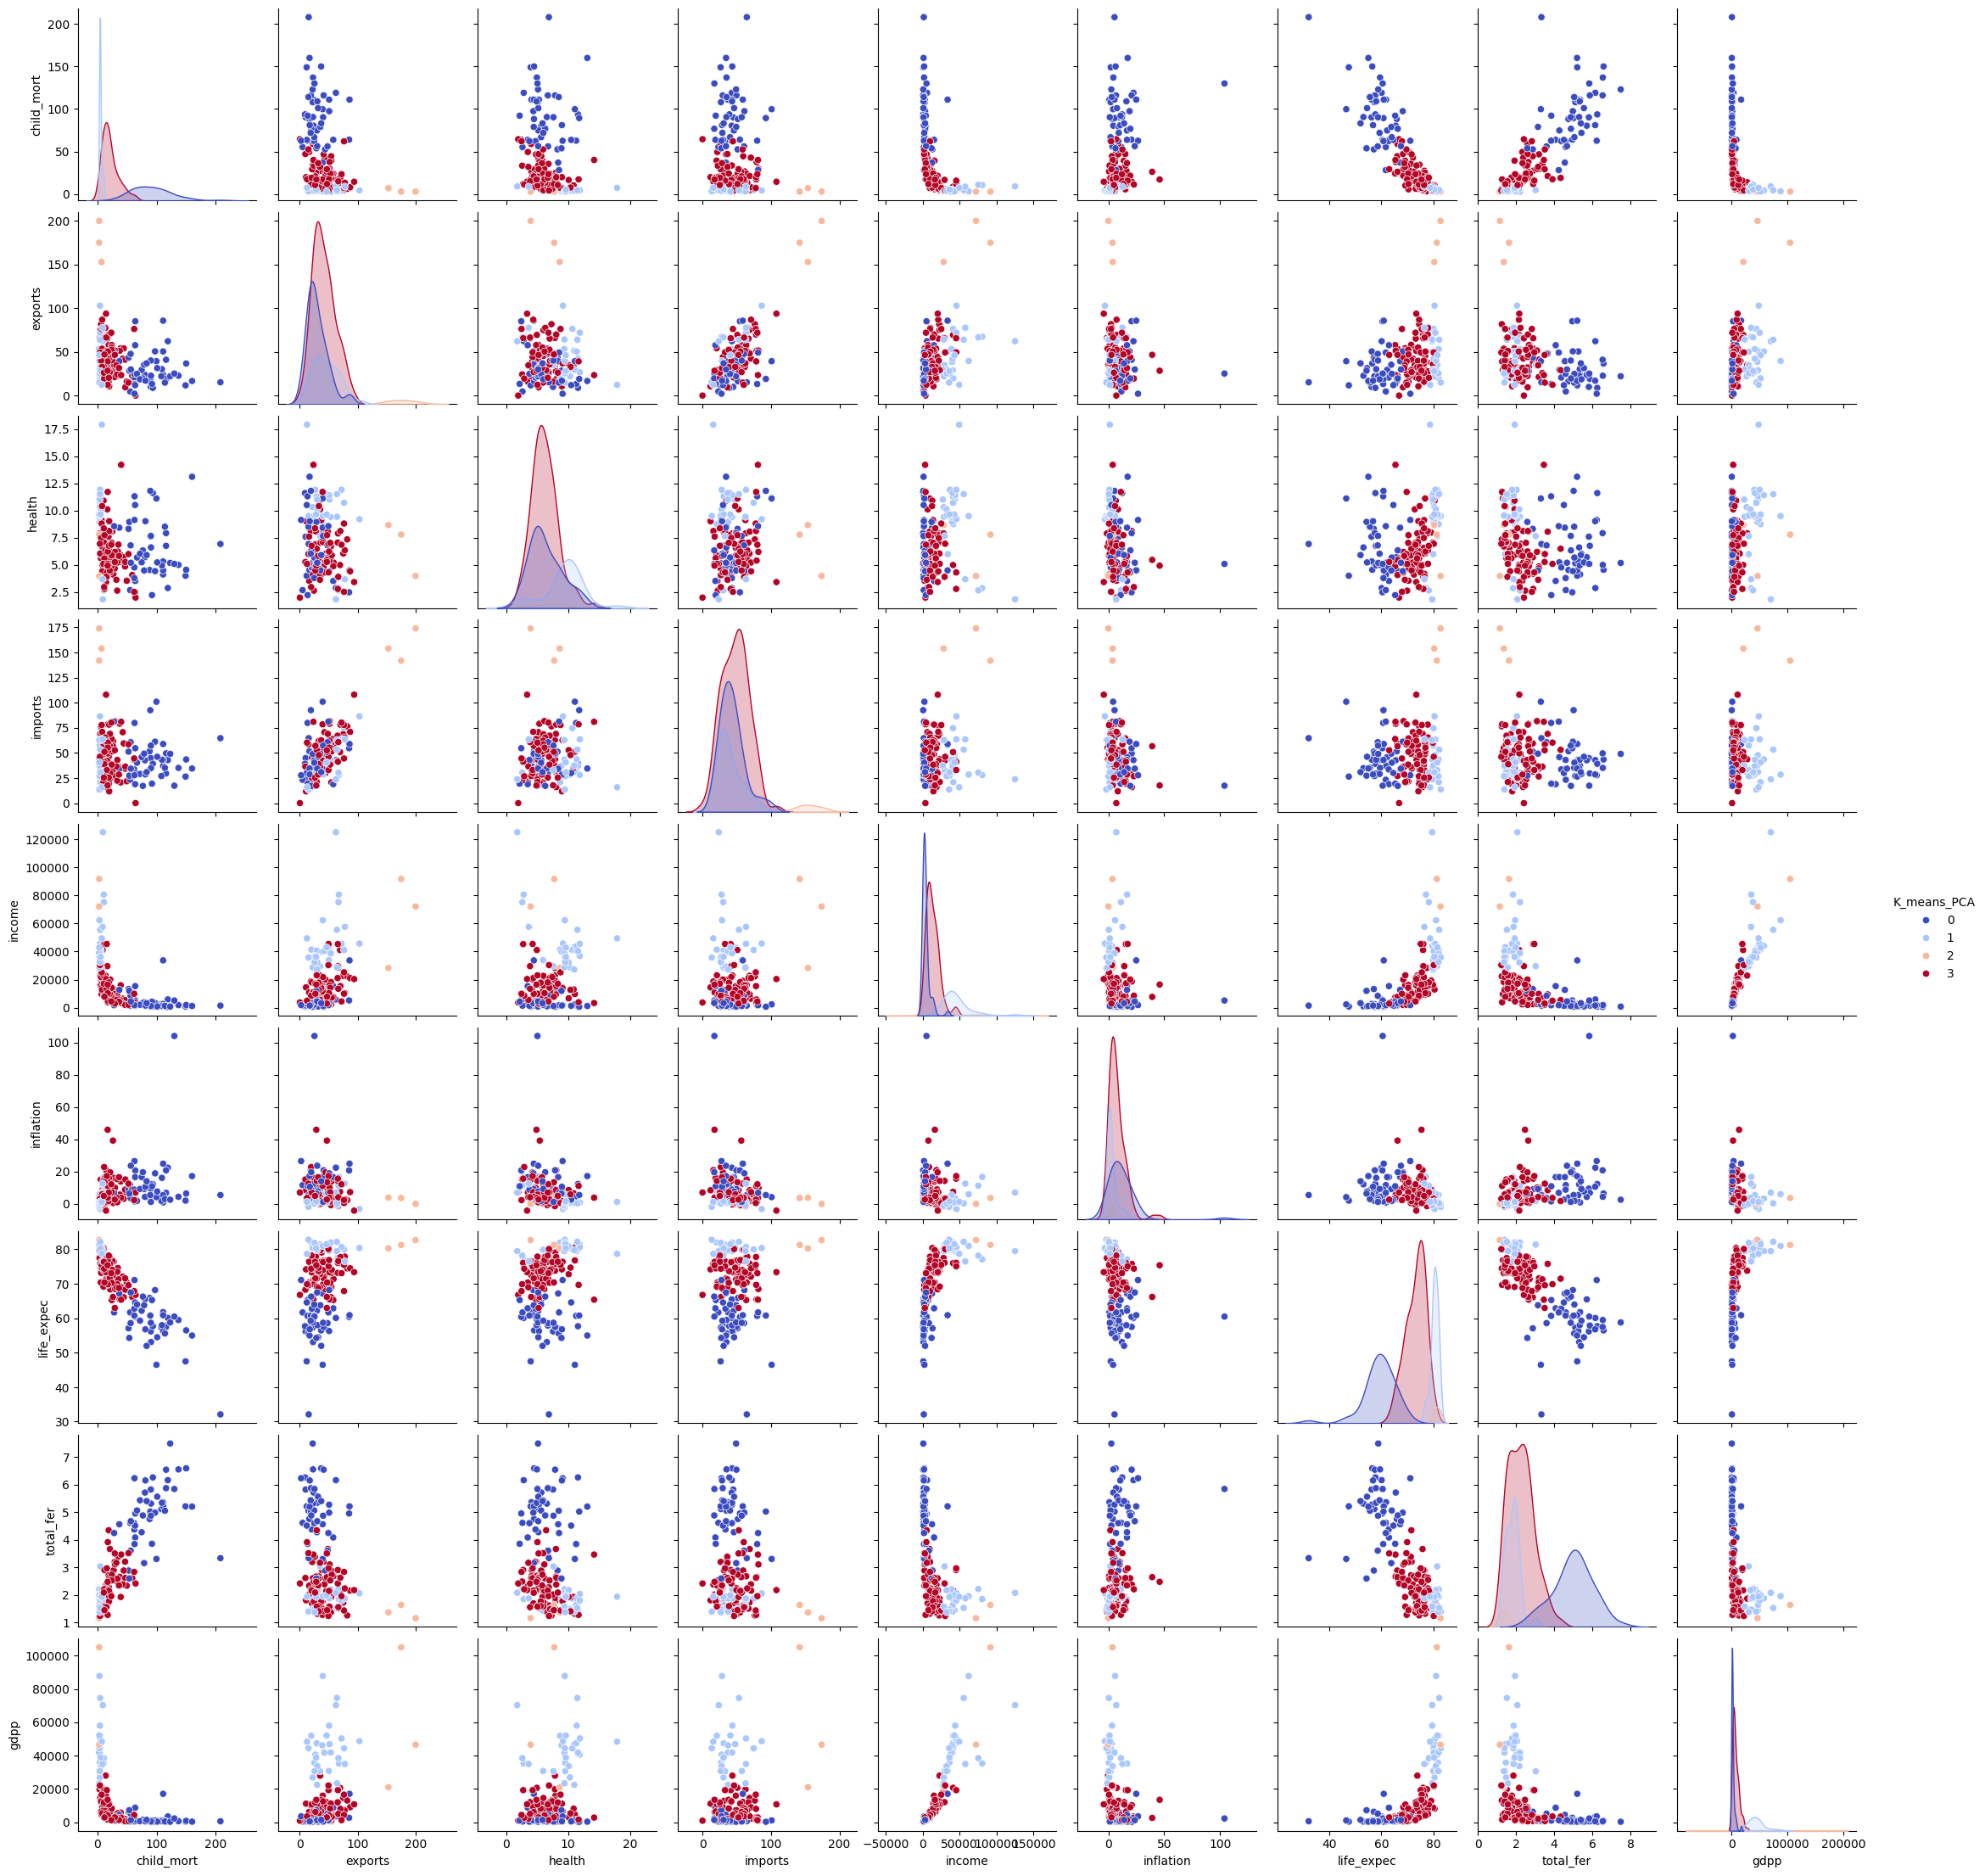

In [53]:
sns.pairplot(data= df_country[['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'K_means_PCA']], hue= 'K_means_PCA', palette='coolwarm')

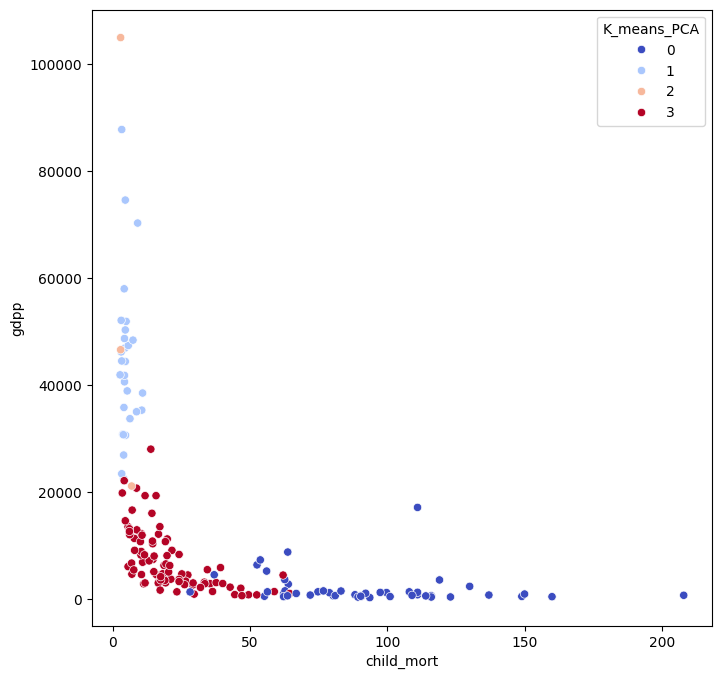

In [56]:
fig = plt.figure(figsize=(8,8))
sns.scatterplot(data= df_country, x='child_mort', y='gdpp', hue='K_means_PCA', palette='coolwarm')
plt.show()